<a href="https://colab.research.google.com/github/imankit23/Comparative-analysis-between-Neuro-symbolic-and-Deep-Learning-IDS/blob/main/graphssage_gnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Update this path based on your extracted file location
file_path = "/content/drive/MyDrive/Colab Notebooks/Gnn Wdnesday fikle.csv"

# Load dataset
df = pd.read_csv(file_path)

# Display first few rows
print(df.head())

# Check dataset info
print(df.info())

# Check for missing values
print(df.isnull().sum())


                                  Flow ID      Source IP   Source Port  \
0  192.168.10.14-209.48.71.168-49459-80-6  192.168.10.14         49459   
1  192.168.10.3-192.168.10.17-389-49453-6  192.168.10.17         49453   
2   192.168.10.3-192.168.10.17-88-46124-6  192.168.10.17         46124   
3  192.168.10.3-192.168.10.17-389-49454-6  192.168.10.17         49454   
4   192.168.10.3-192.168.10.17-88-46126-6  192.168.10.17         46126   

   Destination IP   Destination Port   Protocol      Timestamp  \
0   209.48.71.168                 80          6  5/7/2017 8:42   
1    192.168.10.3                389          6  5/7/2017 8:42   
2    192.168.10.3                 88          6  5/7/2017 8:42   
3    192.168.10.3                389          6  5/7/2017 8:42   
4    192.168.10.3                 88          6  5/7/2017 8:42   

    Flow Duration   Total Fwd Packets   Total Backward Packets  ...  \
0           38308                   1                        1  ...   
1             47

In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")


Number of duplicate rows: 17


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")


Shape after removing duplicates: (692686, 85)


In [ ]:
# Check for missing values
missing_values = df.isnull().sum().sum()
print(f"Total missing values: {missing_values}")


Total missing values: 1007


In [ ]:
# Drop rows with missing values
df.dropna(inplace=True)

# Confirm missing values are removed
missing_values_after = df.isnull().sum().sum()
print(f"Total missing values after removal: {missing_values_after}")


Total missing values after removal: 0


Highly correlated feature pairs (>|0.9| correlation):
(' Flow Duration', 'Fwd IAT Total')
(' Total Fwd Packets', ' Total Backward Packets')
(' Total Fwd Packets', ' Total Length of Bwd Packets')
(' Total Fwd Packets', ' Fwd Header Length')
(' Total Fwd Packets', ' Bwd Header Length')
(' Total Fwd Packets', ' Fwd Header Length.1')
(' Total Fwd Packets', 'Subflow Fwd Packets')
(' Total Fwd Packets', ' Subflow Bwd Packets')
(' Total Fwd Packets', ' Subflow Bwd Bytes')
(' Total Fwd Packets', ' act_data_pkt_fwd')
(' Total Backward Packets', ' Total Length of Bwd Packets')
(' Total Backward Packets', ' Fwd Header Length')
(' Total Backward Packets', ' Bwd Header Length')
(' Total Backward Packets', ' Fwd Header Length.1')
(' Total Backward Packets', 'Subflow Fwd Packets')
(' Total Backward Packets', ' Subflow Bwd Packets')
(' Total Backward Packets', ' Subflow Bwd Bytes')
(' Total Backward Packets', ' act_data_pkt_fwd')
('Total Length of Fwd Packets', ' Subflow Fwd Bytes')
(' Total Length of

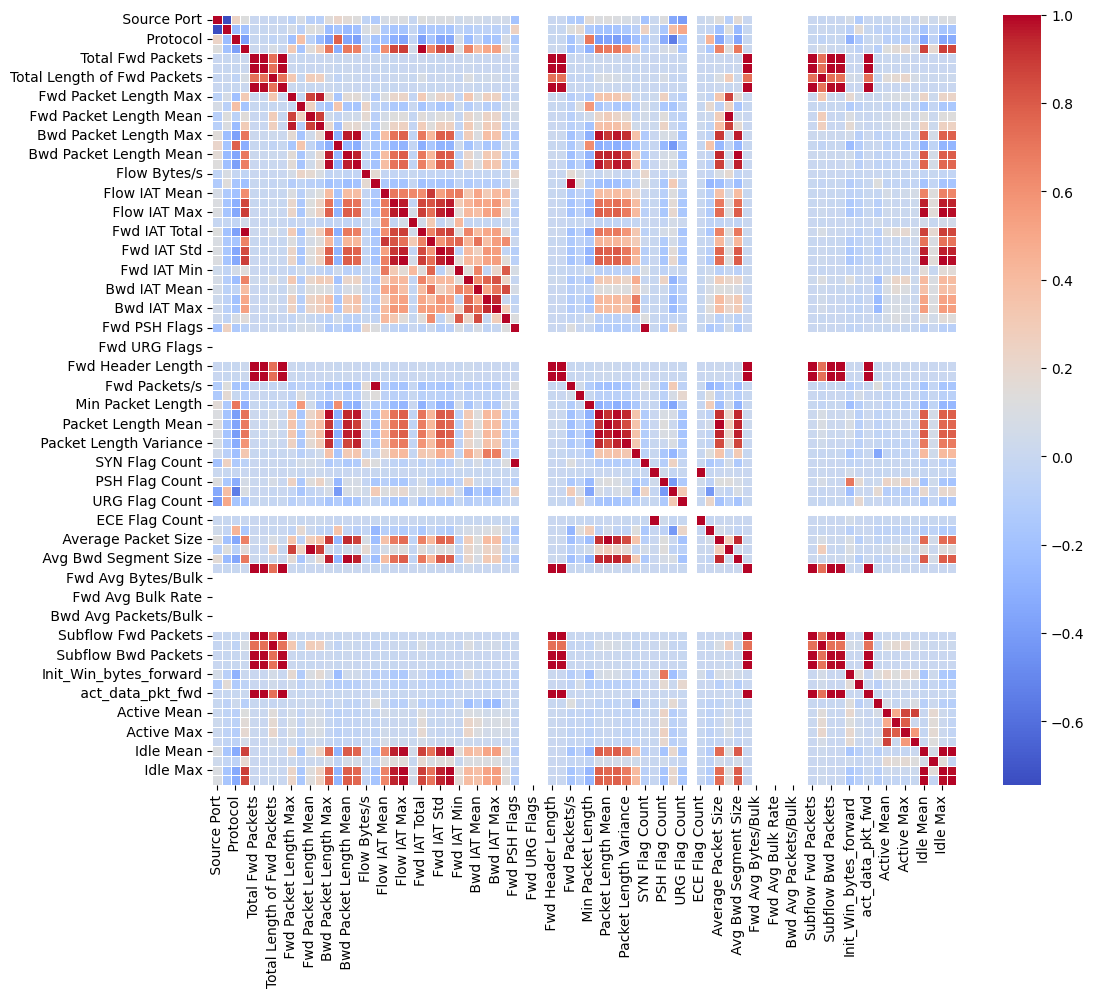

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select only numerical columns
df_numeric = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = df_numeric.corr()

# Set a threshold (e.g., 0.9)
threshold = 0.9

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)

# Identify highly correlated features
high_corr_pairs = np.where(np.abs(corr_matrix) > threshold)
high_corr_pairs = [(corr_matrix.index[i], corr_matrix.columns[j])
                   for i, j in zip(*high_corr_pairs) if i != j and i < j]

print("Highly correlated feature pairs (>|0.9| correlation):")
for pair in high_corr_pairs:
    print(pair)

plt.show()


Dropping 32 highly correlated features:
{' Total Backward Packets', ' Subflow Bwd Packets', ' Flow IAT Max', ' Max Packet Length', ' SYN Flag Count', ' ECE Flag Count', 'Fwd Packets/s', ' Idle Max', ' Fwd Header Length.1', ' Fwd Packet Length Std', ' Packet Length Variance', 'Fwd IAT Total', ' Packet Length Mean', ' Bwd Header Length', ' Fwd IAT Max', ' Avg Fwd Segment Size', ' Subflow Bwd Bytes', ' Idle Min', ' Fwd IAT Std', 'Subflow Fwd Packets', ' Fwd Header Length', ' Bwd Packet Length Std', ' Subflow Fwd Bytes', ' Average Packet Size', ' Avg Bwd Segment Size', ' Packet Length Std', 'Idle Mean', ' act_data_pkt_fwd', ' Fwd IAT Mean', ' Bwd IAT Max', ' Bwd Packet Length Mean', ' Total Length of Bwd Packets'}


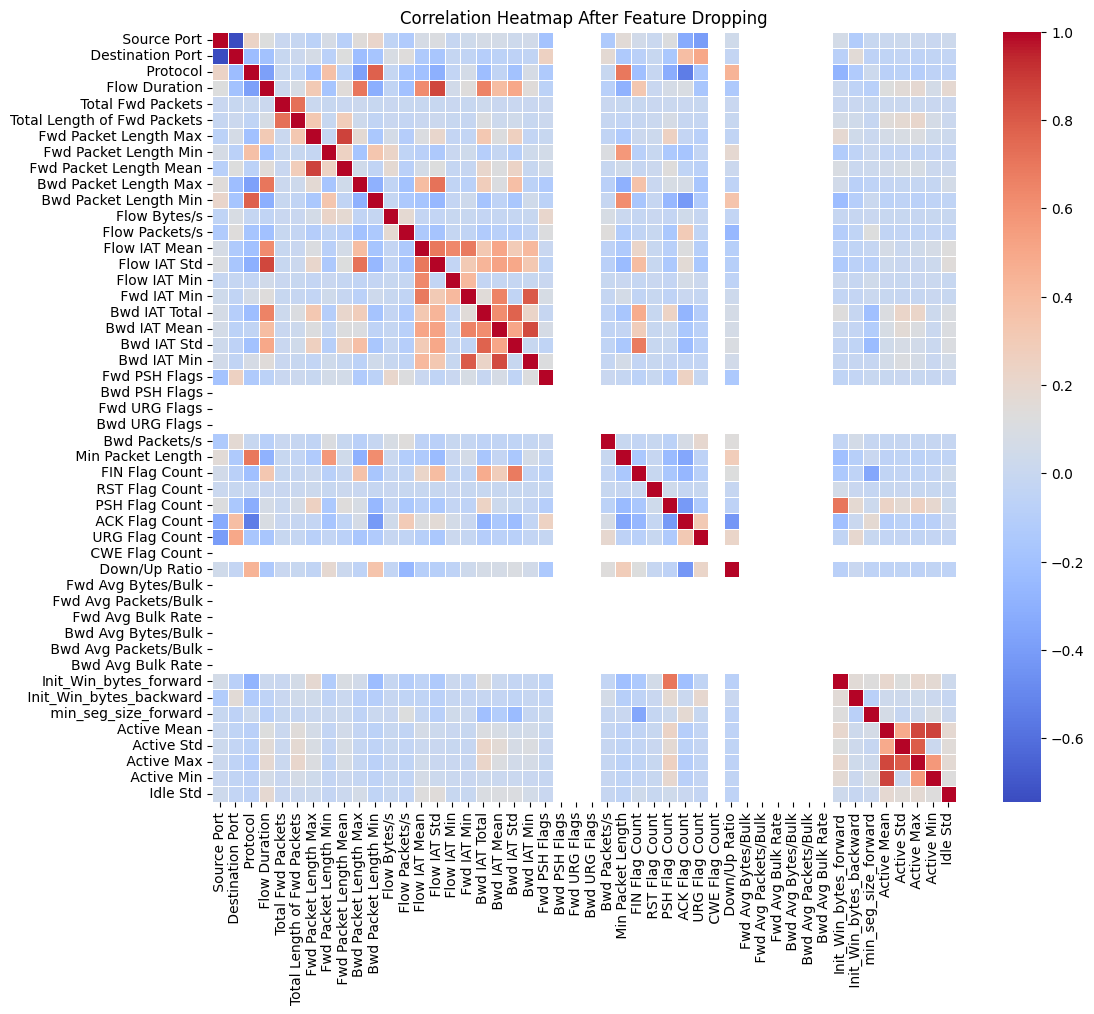

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (ensure you use the cleaned dataset)
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Gnn Wdnesday fikle.csv")  # Change to your actual dataset

# Select numerical columns only
df_numeric = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = df_numeric.corr().abs()

# Set a correlation threshold
threshold = 0.9

# Find highly correlated feature pairs
high_corr_pairs = np.where(corr_matrix > threshold)
high_corr_pairs = [(corr_matrix.index[i], corr_matrix.columns[j]) for i, j in zip(*high_corr_pairs) if i != j and i < j]

# Automatically select features to drop
features_to_drop = set()
for feature1, feature2 in high_corr_pairs:
    if feature1 not in features_to_drop and feature2 not in features_to_drop:
        features_to_drop.add(feature2)  # Drop one of the correlated features

print(f"Dropping {len(features_to_drop)} highly correlated features:")
print(features_to_drop)

# Drop the selected features
df_cleaned = df.drop(columns=features_to_drop, errors='ignore')

# Save the cleaned dataset
df_cleaned.to_csv("cleaned_dataset.csv", index=False)

# Verify with a new correlation heatmap
# Compute correlation matrix using only numeric columns
df_numeric_cleaned = df_cleaned.select_dtypes(include=[np.number])

# Verify with a new correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_numeric_cleaned.corr(), annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap After Feature Dropping")
plt.show()



In [ ]:
# Check for missing values
missing_values = df_cleaned.isnull().sum()
print(missing_values[missing_values > 0])


Flow Bytes/s    1008
dtype: int64


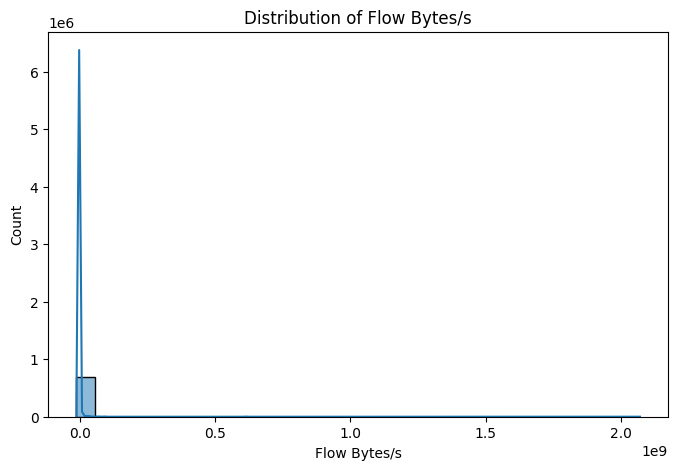

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned['Flow Bytes/s'], kde=True, bins=30)
plt.title('Distribution of Flow Bytes/s')
plt.show()


In [ ]:
df_cleaned = df_cleaned.copy()  # Ensures we modify the actual DataFrame

# Replace inf values with NaN first
df_cleaned['Flow Bytes/s'] = df_cleaned['Flow Bytes/s'].replace([np.inf, -np.inf], np.nan)

# Replace NaN with the 99th percentile of valid values
finite_max = df_cleaned['Flow Bytes/s'].quantile(0.99)
df_cleaned['Flow Bytes/s'] = df_cleaned['Flow Bytes/s'].fillna(finite_max)


In [ ]:
df_cleaned['Flow Bytes/s'] = df_cleaned['Flow Bytes/s'].fillna(df_cleaned['Flow Bytes/s'].median())



In [ ]:
df_cleaned['Flow Bytes/s'] = np.log1p(df_cleaned['Flow Bytes/s'])


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


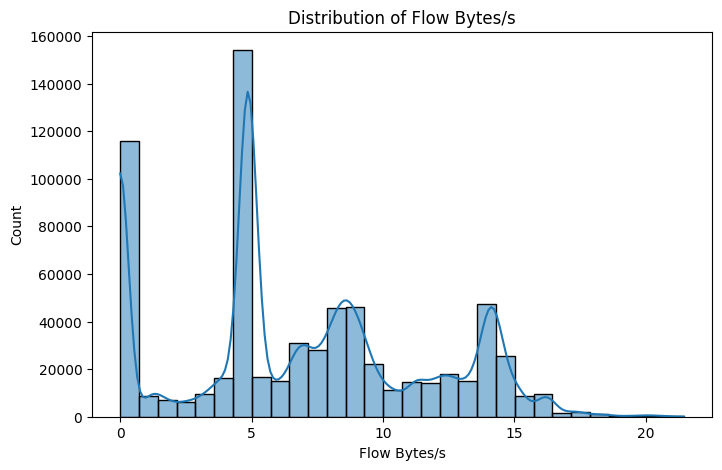

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned['Flow Bytes/s'], kde=True, bins=30)
plt.title('Distribution of Flow Bytes/s')
plt.show()

In [ ]:
# Check for missing values
missing_values = df_cleaned.isnull().sum()
print(missing_values[missing_values > 0])


Flow Bytes/s    16
dtype: int64


In [ ]:


# Now check unique labels
print(df[' Label'].unique())

['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed']


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Define labels
labels = ['BENIGN', 'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye', 'Heartbleed']

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform labels
df_cleaned[' Label'] = label_encoder.fit_transform(df_cleaned[' Label'])

# Mapping of labels
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))


{'BENIGN': np.int64(0), 'DoS GoldenEye': np.int64(1), 'DoS Hulk': np.int64(2), 'DoS Slowhttptest': np.int64(3), 'DoS slowloris': np.int64(4), 'Heartbleed': np.int64(5)}


In [ ]:
print(df_cleaned[' Label'].unique())

[0 4 3 2 1 5]


In [ ]:
import numpy as np

# Check for infinite values in numeric columns only
print(df_cleaned.select_dtypes(include=np.number).apply(np.isinf).sum())

 Source Port                      0
 Destination Port                 0
 Protocol                         0
 Flow Duration                    0
 Total Fwd Packets                0
Total Length of Fwd Packets       0
 Fwd Packet Length Max            0
 Fwd Packet Length Min            0
 Fwd Packet Length Mean           0
Bwd Packet Length Max             0
 Bwd Packet Length Min            0
Flow Bytes/s                      0
 Flow Packets/s                1297
 Flow IAT Mean                    0
 Flow IAT Std                     0
 Flow IAT Min                     0
 Fwd IAT Min                      0
Bwd IAT Total                     0
 Bwd IAT Mean                     0
 Bwd IAT Std                      0
 Bwd IAT Min                      0
Fwd PSH Flags                     0
 Bwd PSH Flags                    0
 Fwd URG Flags                    0
 Bwd URG Flags                    0
 Bwd Packets/s                    0
 Min Packet Length                0
FIN Flag Count              

In [ ]:
df_cleaned[' Flow Packets/s'].replace(np.inf, df_cleaned[' Flow Packets/s'][df_cleaned[' Flow Packets/s'] != np.inf].mean(), inplace=True)


/tmp/ipykernel_1908/3171483923.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[' Flow Packets/s'].replace(np.inf, df_cleaned[' Flow Packets/s'][df_cleaned[' Flow Packets/s'] != np.inf].mean(), inplace=True)


In [ ]:
print(df_cleaned.select_dtypes(include=np.number).apply(np.isinf).sum())

 Source Port                   0
 Destination Port              0
 Protocol                      0
 Flow Duration                 0
 Total Fwd Packets             0
Total Length of Fwd Packets    0
 Fwd Packet Length Max         0
 Fwd Packet Length Min         0
 Fwd Packet Length Mean        0
Bwd Packet Length Max          0
 Bwd Packet Length Min         0
Flow Bytes/s                   0
 Flow Packets/s                0
 Flow IAT Mean                 0
 Flow IAT Std                  0
 Flow IAT Min                  0
 Fwd IAT Min                   0
Bwd IAT Total                  0
 Bwd IAT Mean                  0
 Bwd IAT Std                   0
 Bwd IAT Min                   0
Fwd PSH Flags                  0
 Bwd PSH Flags                 0
 Fwd URG Flags                 0
 Bwd URG Flags                 0
 Bwd Packets/s                 0
 Min Packet Length             0
FIN Flag Count                 0
 RST Flag Count                0
 PSH Flag Count                0
 ACK Flag 

In [ ]:
df_cleaned = df_cleaned.dropna()

In [ ]:
print(df_cleaned.isna().sum())


Flow ID                        0
 Source IP                     0
 Source Port                   0
 Destination IP                0
 Destination Port              0
 Protocol                      0
 Timestamp                     0
 Flow Duration                 0
 Total Fwd Packets             0
Total Length of Fwd Packets    0
 Fwd Packet Length Max         0
 Fwd Packet Length Min         0
 Fwd Packet Length Mean        0
Bwd Packet Length Max          0
 Bwd Packet Length Min         0
Flow Bytes/s                   0
 Flow Packets/s                0
 Flow IAT Mean                 0
 Flow IAT Std                  0
 Flow IAT Min                  0
 Fwd IAT Min                   0
Bwd IAT Total                  0
 Bwd IAT Mean                  0
 Bwd IAT Std                   0
 Bwd IAT Min                   0
Fwd PSH Flags                  0
 Bwd PSH Flags                 0
 Fwd URG Flags                 0
 Bwd URG Flags                 0
 Bwd Packets/s                 0
 Min Packe

In [ ]:
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
import networkx as nx

# 1. Use your existing cleaned and scaled features (X) and labels (y)
# Ensure you have the original IP addresses for graph construction
# Note: You'll need to extract Source/Destination IPs before dropping them in your earlier code
source_ips = df[' Source IP']
dest_ips = df[' Destination IP']

# Convert scaled features and labels to PyTorch tensors
x_tensor = torch.tensor(X, dtype=torch.float)
y_tensor = torch.tensor(y.values, dtype=torch.long)


In [ ]:
from sklearn.model_selection import train_test_split

X = df_scaled  # Features (scaled)
y = df_cleaned[' Label']  # Target column

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
def build_edge_index(df):
    # Map each row index to a node
    df = df.reset_index(drop=True)
    df['node_id'] = df.index

    # Group by Source IP to find flows coming from the same host
    source_groups = df.groupby(' Source IP')['node_id'].apply(list)

    edge_sources = []
    edge_targets = []

    for nodes in source_groups:
        if len(nodes) > 1:
            # Connect all flows from the same IP (Fully connected sub-graph for that IP)
            # For massive datasets, consider connecting only consecutive flows to save memory
            for i in range(len(nodes) - 1):
                edge_sources.append(nodes[i])
                edge_targets.append(nodes[i+1])
                # GraphSAGE usually works on undirected-style indexing
                edge_sources.append(nodes[i+1])
                edge_targets.append(nodes[i])

    return torch.tensor([edge_sources, edge_targets], dtype=torch.long)

edge_index = build_edge_index(df_cleaned) # Use the DF before it was fully dropped to X


In [ ]:
# Create masks based on your existing train_test_split indices
num_nodes = x_tensor.size(0)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

# Assuming X_train/X_test were split using indices
train_idx, test_idx = train_test_split(range(num_nodes), test_size=0.2, random_state=42)

train_mask[train_idx] = True
test_mask[test_idx] = True

# Encapsulate into PyG Data object
graph_data = Data(
    x=x_tensor,
    edge_index=edge_index,
    y=y_tensor,
    train_mask=train_mask,
    test_mask=test_mask
)

print(f"Graph Structure: {graph_data}")


Graph Structure: Data(x=[692687, 48], edge_index=[2, 1369996], y=[692687], train_mask=[692687], test_mask=[692687])


In [ ]:
from torch_geometric.loader import NeighborLoader

train_loader = NeighborLoader(
    graph_data,
    num_neighbors=[15, 10], # Sample 15 neighbors for 1st hop, 10 for 2nd
    batch_size=1024,
    input_nodes=graph_data.train_mask,
    shuffle=True
)

# Usage in training loop:
# for batch in train_loader:
#     out = model(batch.x, batch.edge_index)


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGEModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphSAGEModel, self).__init__()
        # Layer 1: Aggregates neighbor features
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        # Layer 2: Produces final class embeddings
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # x: Node features, edge_index: Graph connectivity
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index)
        return x


In [ ]:
from sklearn.metrics import classification_report
from sklearn.utils import class_weight
import numpy as np

# 1. Setup Device and Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_features = graph_data.x.shape[1]
num_classes = len(torch.unique(graph_data.y))

model = GraphSAGEModel(num_features, 128, num_classes).to(device)
graph_data = graph_data.to(device)

# Calculate class weights for imbalanced datasets
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(graph_data.y.cpu().numpy()), # Use all possible classes from the full dataset
    y=y_train.values # Compute weights based on training labels - Fixed: Use .values for pandas Series
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# 2. Define Loss with Class Weights
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 3. Training Loop
def train():
    model.train()
    optimizer.zero_grad()
    out = model(graph_data.x, graph_data.edge_index)
    # Only calculate loss on training nodes
    loss = criterion(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# 4. Evaluation Function
@torch.no_grad()
def test():
    model.eval()
    out = model(graph_data.x, graph_data.edge_index)
    preds = out.argmax(dim=1)

    # Calculate accuracy for test mask
    correct = (preds[graph_data.test_mask] == graph_data.y[graph_data.test_mask]).sum()
    acc = int(correct) / int(graph_data.test_mask.sum())
    return acc, preds

# --- Run Training ---
for epoch in range(1, 201):
    loss = train()
    if epoch % 20 == 0:
        test_acc, _ = test()
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Test Acc: {test_acc:.4f}')

# --- Final Classification Report ---
_, final_preds = test()
y_true = graph_data.y[graph_data.test_mask].cpu().numpy()
y_pred = final_preds[graph_data.test_mask].cpu().numpy()

print("\nFinal Report:")
# Assuming 'label_encoder' (LabelEncoder) is accessible from a previous cell where it was fitted
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))


Epoch: 020, Loss: 0.0739, Test Acc: 0.9719
Epoch: 040, Loss: 0.0288, Test Acc: 0.9918
Epoch: 060, Loss: 0.0182, Test Acc: 0.9936
Epoch: 080, Loss: 0.0133, Test Acc: 0.9956
Epoch: 100, Loss: 0.0111, Test Acc: 0.9964
Epoch: 120, Loss: 0.0096, Test Acc: 0.9970
Epoch: 140, Loss: 0.0080, Test Acc: 0.9973
Epoch: 160, Loss: 0.0075, Test Acc: 0.9977
Epoch: 180, Loss: 0.0062, Test Acc: 0.9980
Epoch: 200, Loss: 0.0057, Test Acc: 0.9981

Final Report:
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00     88088
   DoS GoldenEye       0.97      1.00      0.98      2057
        DoS Hulk       1.00      1.00      1.00     46180
DoS Slowhttptest       0.99      0.99      0.99      1085
   DoS slowloris       0.94      1.00      0.97      1126
      Heartbleed       1.00      1.00      1.00         2

        accuracy                           1.00    138538
       macro avg       0.98      1.00      0.99    138538
    weighted avg       1.00    

In [ ]:
import torch
from sklearn.metrics import accuracy_score, classification_report

# 1. Switch model to evaluation mode
model.eval()

# 2. Perform a forward pass on the full graph
with torch.no_grad():
    # out contains the probabilities/logits for ALL nodes in the graph
    out = model(graph_data.x, graph_data.edge_index)

    # 3. Get predictions (argmax) for the TEST nodes only
    y_pred_sage = out[graph_data.test_mask].argmax(dim=1).cpu().numpy()
    y_test_sage = graph_data.y[graph_data.test_mask].cpu().numpy()

# 4. Accuracy
accuracy_sage = accuracy_score(y_test_sage, y_pred_sage)
print(f"Test Accuracy (GraphSAGE): {accuracy_sage:.6f}")

# 5. Classification Report
# le.classes_ provides the original names (BENIGN, DoS, etc.)
print("Classification Report (GraphSAGE):\n",
      classification_report(y_test_sage, y_pred_sage, target_names=label_encoder.classes_))

Test Accuracy (GraphSAGE): 0.998123
Classification Report (GraphSAGE):
                   precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00     88088
   DoS GoldenEye       0.97      1.00      0.98      2057
        DoS Hulk       1.00      1.00      1.00     46180
DoS Slowhttptest       0.99      0.99      0.99      1085
   DoS slowloris       0.94      1.00      0.97      1126
      Heartbleed       1.00      1.00      1.00         2

        accuracy                           1.00    138538
       macro avg       0.98      1.00      0.99    138538
    weighted avg       1.00      1.00      1.00    138538

